# Imports and Setup

In [ ]:
import argparse
import os
import sys
import json
import time
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)

warnings.filterwarnings('ignore')

# Global Plotting Config
OUTPUT_DIR = 'results/plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)
COLORS = {
    'primary': '#1f4e79', 'accent': '#2e75b6', 'light': '#bdd7ee',
    'success': '#70ad47', 'warning': '#ffc000', 'danger': '#c00000',
    'normal': '#4472c4', 'attack': '#ed7d31', 'full': '#1f4e79', 'light_m': '#70ad47',
}

# Accessing the Data

In [ ]:
!unzip -q NSL-KDD.zip -d ./nsl-kdd

# Verify the files are there

print("Files in directory:", os.listdir('./nsl-kdd'))

Files in directory: ['KDDTest-21.txt', 'KDDTest+.txt', 'KDDTrain+.txt', 'nsl-kdd', 'KDDTest-21.arff', 'KDDTest+.arff', 'KDDTrain+_20Percent.arff', 'KDDTrain+_20Percent.txt', 'KDDTrain+.arff', 'index.html', 'KDDTest1.jpg', 'KDDTrain1.jpg']


# Preprocessing Module

In [ ]:
COLUMN_NAMES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

ATTACK_MAP = {
    'normal': 'normal',
    'back': 'dos', 'land': 'dos', 'neptune': 'dos', 'pod': 'dos',
    'smurf': 'dos', 'teardrop': 'dos', 'apache2': 'dos', 'udpstorm': 'dos',
    'processtable': 'dos', 'worm': 'dos', 'mailbomb': 'dos',
    'satan': 'probe', 'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe',
    'mscan': 'probe', 'saint': 'probe',
    'guess_passwd': 'r2l', 'ftp_write': 'r2l', 'imap': 'r2l', 'phf': 'r2l',
    'multihop': 'r2l', 'warezmaster': 'r2l', 'warezclient': 'r2l',
    'spy': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'snmpguess': 'r2l',
    'snmpgetattack': 'r2l', 'httptunnel': 'r2l', 'sendmail': 'r2l',
    'named': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'rootkit': 'u2r',
    'perl': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r', 'ps': 'u2r',
}

CATEGORICAL_COLS = ['protocol_type', 'service', 'flag']

def load_dataset(filepath, has_difficulty=True):
    cols = COLUMN_NAMES if has_difficulty else COLUMN_NAMES[:-1]
    df = pd.read_csv(filepath, header=None, names=cols)
    return df

def map_attack_labels(df):
    df = df.copy()
    df['attack_category'] = df['label'].str.strip().str.lower().map(lambda x: ATTACK_MAP.get(x, 'unknown'))
    df['attack_category'] = df['attack_category'].replace('unknown', 'other')
    return df

def binary_label(df):
    df = df.copy()
    df['binary_label'] = df['attack_category'].apply(lambda x: 0 if x == 'normal' else 1)
    return df

def encode_categoricals(df, encoders=None, fit=True):
    df = df.copy()
    if fit:
        encoders = {}
        for col in CATEGORICAL_COLS:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
    else:
        for col in CATEGORICAL_COLS:
            le = encoders[col]
            df[col] = df[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    return df, encoders

def scale_features(X_train, X_test=None, scaler=None, fit=True):
    if fit:
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test) if X_test is not None else None
    else:
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test) if X_test is not None else None
    return X_train_scaled, X_test_scaled, scaler

def select_features(X_train, y_train, X_test=None, k=20):
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test) if X_test is not None else None
    return X_train_sel, X_test_sel, selector

def preprocess_pipeline(train_path, test_path, output_dir='processed', n_features=20):
    os.makedirs(output_dir, exist_ok=True)
    train_df = load_dataset(train_path)
    test_df  = load_dataset(test_path)
    for df in [train_df, test_df]:
        if 'difficulty' in df.columns: df.drop(columns=['difficulty'], inplace=True)
    train_df = map_attack_labels(train_df)
    test_df  = map_attack_labels(test_df)
    train_df = binary_label(train_df)
    test_df  = binary_label(test_df)
    train_df, encoders = encode_categoricals(train_df, fit=True)
    test_df, _         = encode_categoricals(test_df, encoders=encoders, fit=False)
    feature_cols = [c for c in COLUMN_NAMES if c not in ['label', 'difficulty', 'attack_category', 'binary_label']]
    X_train = train_df[feature_cols].values.astype(np.float32)
    y_train = train_df['binary_label'].values
    X_test  = test_df[feature_cols].values.astype(np.float32)
    y_test  = test_df['binary_label'].values
    X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test, fit=True)
    X_train_sel, X_test_sel, selector = select_features(X_train_scaled, y_train, X_test_scaled, k=n_features)
    return {
        'X_train': X_train_sel, 'X_test': X_test_sel, 'y_train': y_train, 'y_test': y_test,
        'train_df': train_df, 'test_df': test_df
    }

# Model Module

In [ ]:
MODEL_CONFIGS = {
    'full': {'hidden_layer_sizes': (128, 64, 32), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-4, 'batch_size': 256, 'max_iter': 100, 'early_stopping': True, 'random_state': 42},
    'light': {'hidden_layer_sizes': (64, 32), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-3, 'batch_size': 512, 'max_iter': 50, 'early_stopping': True, 'random_state': 42}
}

def build_model(variant='full'):
    return MLPClassifier(**MODEL_CONFIGS[variant])

def train_model(model, X_train, y_train, model_name='ids_model'):
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    return model, elapsed

def evaluate_model(model, X_test, y_test, model_name='ids_model'):
    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start
    per_sample_time_ms = (inference_time / len(X_test)) * 1000
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='binary', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='binary', zero_division=0),
        'per_sample_ms': per_sample_time_ms,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    return metrics, y_pred

def count_parameters(model):
    total = 0
    if hasattr(model, 'coefs_'):
        for lw in model.coefs_: total += lw.size
        for lb in model.intercepts_: total += lb.size
    return total

# Visualization Module

In [ ]:
def plot_dataset_distribution(train_df, test_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (df, title) in zip(axes, [(train_df, 'Training Set'), (test_df, 'Test Set')]):
        counts = df['attack_category'].value_counts()
        ax.bar(counts.index, counts.values, color=COLORS['primary'])
        ax.set_title(title)
    plt.savefig(os.path.join(OUTPUT_DIR, 'dataset_distribution.png'))
    plt.show()

def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_{model_name}.png'))
    plt.show()

def plot_model_comparison(metrics_full, metrics_light):
    # These are the labels for the chart
    display_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    # These MUST match the keys in your metrics dictionary: 'accuracy', 'precision', 'recall', 'f1'
    keys = ['accuracy', 'precision', 'recall', 'f1']

    x = np.arange(len(display_labels))
    width = 0.4

    plt.figure(figsize=(10, 6))
    plt.bar(x - 0.2, [metrics_full[k] for k in keys], width, label='Full DNN', color=COLORS['full'])
    plt.bar(x + 0.2, [metrics_light[k] for k in keys], width, label='Lightweight DNN', color=COLORS['light_m'])

    plt.xticks(x, display_labels)
    plt.ylabel('Score (0.0 - 1.0)')
    plt.title('Model Performance Comparison')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'comparison.png'))
    plt.show()

def plot_resource_comparison(m_full, m_light, t_full, t_light):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].bar(['Full', 'Light'], [t_full, t_light], color=COLORS['accent'])
    axes[0].set_title('Training Time (s)')
    axes[1].bar(['Full', 'Light'], [m_full['per_sample_ms'], m_light['per_sample_ms']], color=COLORS['success'])
    axes[1].set_title('Inference Latency (ms/sample)')
    plt.savefig(os.path.join(OUTPUT_DIR, 'resources.png'))
    plt.show()

# Execution Pipeline

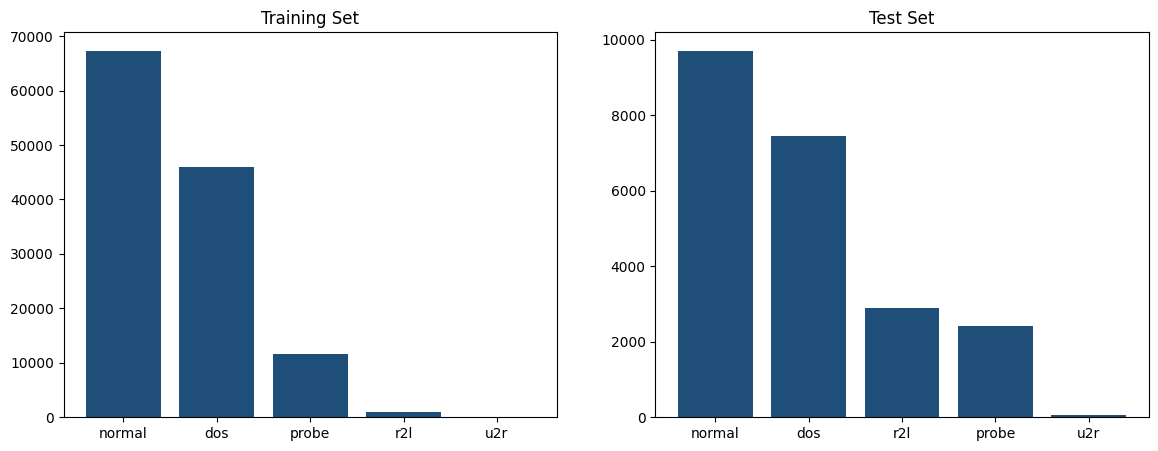

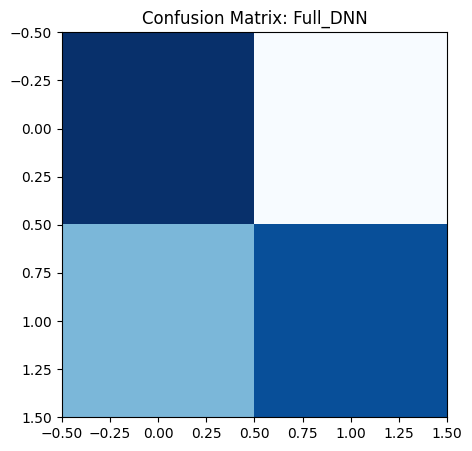

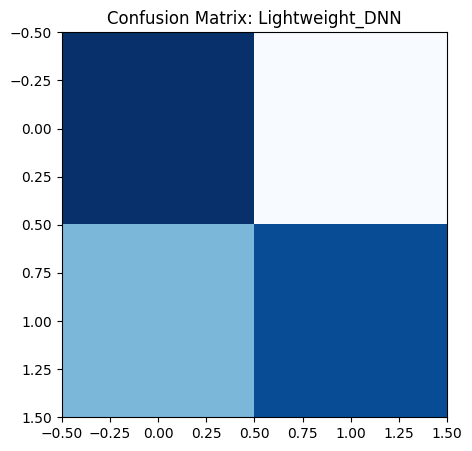

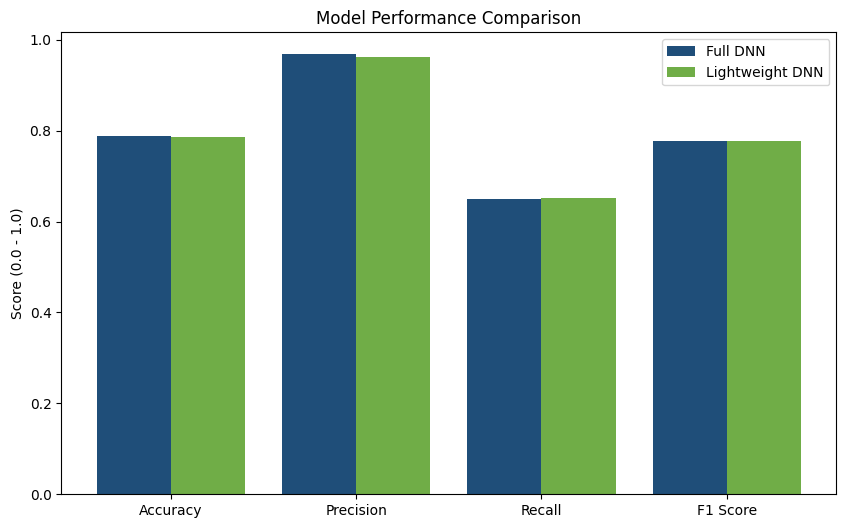

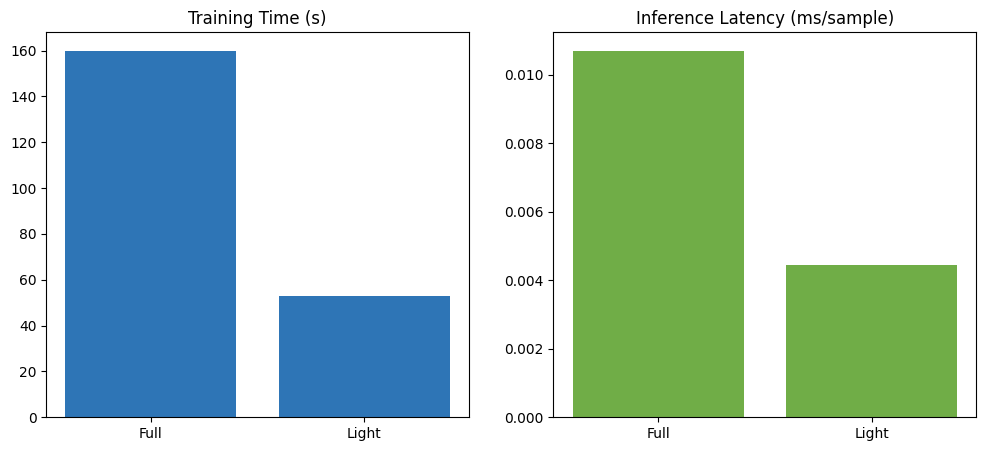


FINAL SUMMARY (GROUP 4)
Metric               Full       Light
Accuracy             78.87% 78.70%
Train Time           159.98s    52.83s
Params               13057      3457


In [ ]:
# --- CONFIGURATION ---
DATASET_DIR = './nsl-kdd'
TRAIN_FILE = 'KDDTrain+.txt'
TEST_FILE = 'KDDTest+.txt'
N_FEATURES = 20

def run_pipeline():
    # Phase 1: Preprocessing
    train_path = os.path.join(DATASET_DIR, TRAIN_FILE)
    test_path  = os.path.join(DATASET_DIR, TEST_FILE)

    if not os.path.exists(train_path):
        print(f"[ERROR] Could not find {train_path}. Please upload the dataset.")
        return

    data = preprocess_pipeline(train_path, test_path, n_features=N_FEATURES)

# Phase 2: Visualisation
    plot_dataset_distribution(data['train_df'], data['test_df'])

    # Phase 3 & 4: Training
    model_full = build_model('full')
    model_full, t_full = train_model(model_full, data['X_train'], data['y_train'], 'Full DNN')

    model_light = build_model('light')
    model_light, t_light = train_model(model_light, data['X_train'], data['y_train'], 'Lightweight DNN')

    # Phase 5: Evaluation
    m_full, _  = evaluate_model(model_full, data['X_test'], data['y_test'], 'Full DNN')
    m_light, _ = evaluate_model(model_light, data['X_test'], data['y_test'], 'Lightweight DNN')

    # Phase 6: Results Comparison
    plot_confusion_matrix(m_full['confusion_matrix'], 'Full_DNN')
    plot_confusion_matrix(m_light['confusion_matrix'], 'Lightweight_DNN')
    plot_model_comparison(m_full, m_light)
    plot_resource_comparison(m_full, m_light, t_full, t_light)

    # Final Summary Table
    print("\n" + "="*30)
    print("FINAL SUMMARY (GROUP 4)")
    print("="*30)
    print(f"{'Metric':<20} {'Full':<10} {'Light'}")
    print(f"{'Accuracy':<20} {m_full['accuracy']*100:.2f}% {m_light['accuracy']*100:.2f}%")
    print(f"{'Train Time':<20} {t_full:.2f}s    {t_light:.2f}s")
    print(f"{'Params':<20} {count_parameters(model_full):<10} {count_parameters(model_light)}")

run_pipeline()

